In [1]:
# ─── Kütüphanelerin İçe Aktarılması ───────────────────────────────────────────
import numpy as np                      # sayısal hesaplamalar
import pandas as pd                     # veri işleme
import matplotlib.pyplot as plt         # görselleştirme
import seaborn as sns

from sklearn.ensemble import IsolationForest      # anomali tespiti
from sklearn.preprocessing import StandardScaler  # özellik ölçekleme
from sklearn.decomposition import PCA             # 2B görselleştirme için boyut indirgeme
from sklearn.svm import OneClassSVM               # karşılaştırma modeli
from sklearn.neighbors import LocalOutlierFactor  # karşılaştırma modeli
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
# ─── Veri Setinin Yüklenmesi ──────────────────────────────────────────────────
df = pd.read_csv("creditcard_ornek.csv.gz")

print(f"Boyut : {df.shape[0]:,} işlem × {df.shape[1]} sütun")
print(f"Eksik değer: {df.isnull().sum().sum()}")
df.head()

Boyut : 60,000 işlem × 31 sütun
Eksik değer: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,104961.0,-0.926649,1.811247,1.047280,0.472509,-0.369324,-0.429768,-0.796277,-4.381794,0.895850,...,3.362698,-2.299212,0.133479,0.871059,1.344556,0.541878,0.140929,0.169766,5.38,0
1,121666.0,-4.976806,-8.135363,-2.062798,-0.375502,-2.585125,0.670861,3.306906,-1.486843,0.651170,...,2.444483,-1.329118,-2.623180,0.675876,0.157246,0.355935,-0.431604,0.642691,2604.00,0
2,40640.0,-2.784389,2.242021,0.130575,0.590729,0.924384,0.238615,-5.016400,-9.260696,1.432011,...,9.139879,-3.614018,-1.842699,0.361865,-0.022376,-0.485892,0.741703,0.449246,7.17,0
3,1914.0,0.748191,-1.041900,1.031218,0.507513,-1.542961,-0.480101,-0.312863,-0.050804,1.089734,...,-0.069211,-0.437001,-0.085490,0.822241,0.023996,0.896132,-0.073521,0.058383,236.60,0
4,161140.0,-0.867298,-1.346464,-0.274388,-0.107682,2.164562,-2.133021,-0.261130,-0.008457,0.061359,...,0.208225,0.159399,0.756463,0.067808,-2.069685,-0.114241,0.233039,0.376153,19.16,0


In [3]:
# ─── Hedef Dağılımı: Dolandırıcılık ne kadar nadir? ───────────────────────────
sayim = df["Class"].value_counts()
oran  = df["Class"].mean()

print(f"Normal işlem       : {sayim[0]:,}")
print(f"Dolandırıcılık     : {sayim[1]:,}")
print(f"Dolandırıcılık oranı: %{oran*100:.3f}")
print(f"\nYani ~{int(1/oran):,} işlemde 1 tanesi sahte.")

Normal işlem       : 59,896
Dolandırıcılık     : 104
Dolandırıcılık oranı: %0.173

Yani ~576 işlemde 1 tanesi sahte.


In [4]:
# ─── İstatistiksel Özet (Time ve Amount) ──────────────────────────────────────
# V1..V28 sütunları gizlilik nedeniyle PCA ile dönüştürülmüş, ham hâlleri yok
df[["Time", "Amount"]].describe().round(2)

,Time,Amount
count,60000.00,60000.00
mean,94851.92,87.87
std,47421.14,252.01
min,0.00,0.00
25%,54328.00,5.78
50%,84691.50,22.00
75%,139246.50,76.91
max,172792.00,25691.16


In [5]:
# ─── Normal vs Dolandırıcılık: Tutar karşılaştırması ──────────────────────────
print(df.groupby("Class")["Amount"].agg(["count", "mean", "median", "max"]).round(2))

       count    mean  median       max
Class                                 
0      59896   87.84   22.00  25691.16
1        104  104.29    7.36   1335.00


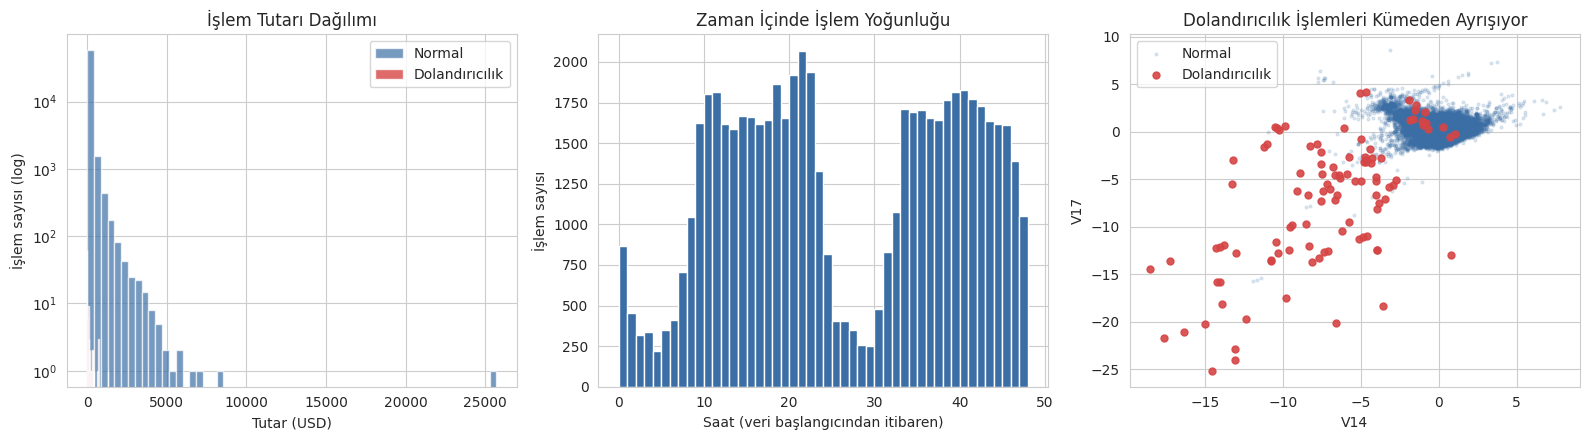

In [6]:
# ─── Ham Veri Görselleştirmesi ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) İşlem tutarı dağılımı (log ölçek)
axes[0].hist(df.loc[df["Class"] == 0, "Amount"] + 1, bins=60, color="#3b6ea5",
             alpha=0.7, label="Normal", log=True)
axes[0].hist(df.loc[df["Class"] == 1, "Amount"] + 1, bins=60, color="#d64545",
             alpha=0.8, label="Dolandırıcılık", log=True)
axes[0].set_xlabel("Tutar (USD)"); axes[0].set_ylabel("İşlem sayısı (log)")
axes[0].set_title("İşlem Tutarı Dağılımı"); axes[0].legend()

# 2) Zamana göre işlem yoğunluğu
axes[1].hist(df["Time"] / 3600, bins=48, color="#3b6ea5")
axes[1].set_xlabel("Saat (veri başlangıcından itibaren)"); axes[1].set_ylabel("İşlem sayısı")
axes[1].set_title("Zaman İçinde İşlem Yoğunluğu")

# 3) En ayırt edici iki PCA bileşeni
axes[2].scatter(df.loc[df["Class"] == 0, "V14"], df.loc[df["Class"] == 0, "V17"],
                s=4, alpha=0.15, color="#3b6ea5", label="Normal")
axes[2].scatter(df.loc[df["Class"] == 1, "V14"], df.loc[df["Class"] == 1, "V17"],
                s=25, alpha=0.9, color="#d64545", label="Dolandırıcılık")
axes[2].set_xlabel("V14"); axes[2].set_ylabel("V17")
axes[2].set_title("Dolandırıcılık İşlemleri Kümeden Ayrışıyor"); axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
# ─── Özellik / Etiket Ayrımı ──────────────────────────────────────────────────
# Time düşürülüyor: mutlak zaman damgası anomali sinyali taşımaz
ozellikler = [c for c in df.columns if c not in ["Class", "Time"]]
X = df[ozellikler]
y = df["Class"]

# Isolation Forest ETİKETSİZ çalışır; y sadece SONUÇLARI DEĞERLENDİRMEK için kullanılacak
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Eğitim: {X_train.shape[0]:,} işlem ({y_train.sum()} dolandırıcılık)")
print(f"Test  : {X_test.shape[0]:,} işlem ({y_test.sum()} dolandırıcılık)")

Eğitim: 42,000 işlem (73 dolandırıcılık)
Test  : 18,000 işlem (31 dolandırıcılık)


In [8]:
# ─── Özellik Ölçekleme ────────────────────────────────────────────────────────
# fit SADECE eğitim verisine (veri sızıntısı önlemi)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Ölçekleme sonrası eğitim ortalamaları ~0:", X_train_s.mean(axis=0)[:5].round(3))
print("Ölçekleme sonrası eğitim std'leri   ~1:", X_train_s.std(axis=0)[:5].round(3))

Ölçekleme sonrası eğitim ortalamaları ~0: [-0. -0.  0. -0.  0.]
Ölçekleme sonrası eğitim std'leri   ~1: [1. 1. 1. 1. 1.]


In [9]:
# ─── Isolation Forest Modeli ──────────────────────────────────────────────────
iso = IsolationForest(
    n_estimators=200,        # 200 izolasyon ağacı
    contamination=0.0017,    # beklenen anomali oranı (gerçek orana yakın seçildi)
    max_samples=256,         # her ağaç 256 örnekle eğitilir (algoritmanın standardı)
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_train_s)
print("Model eğitildi ✓  — dikkat: etiketler (y_train) HİÇ kullanılmadı")

Model eğitildi ✓  — dikkat: etiketler (y_train) HİÇ kullanılmadı


In [10]:
# ─── Test Verisi Üzerinde Tahmin ──────────────────────────────────────────────
tahmin_ham = iso.predict(X_test_s)          # +1 = normal, -1 = anomali
y_pred = (tahmin_ham == -1).astype(int)     # 1 = anomali olarak işaretlendi

skorlar = iso.decision_function(X_test_s)   # düşük skor = daha anormal

print(f"Anomali olarak işaretlenen: {y_pred.sum()} işlem (%{y_pred.mean()*100:.2f})")
print(f"Gerçekte dolandırıcılık   : {y_test.sum()} işlem")

Anomali olarak işaretlenen: 30 işlem (%0.17)
Gerçekte dolandırıcılık   : 31 işlem


                precision    recall  f1-score   support

        Normal      0.999     0.999     0.999     17969
Dolandırıcılık      0.333     0.323     0.328        31

      accuracy                          0.998     18000
     macro avg      0.666     0.661     0.663     18000
  weighted avg      0.998     0.998     0.998     18000



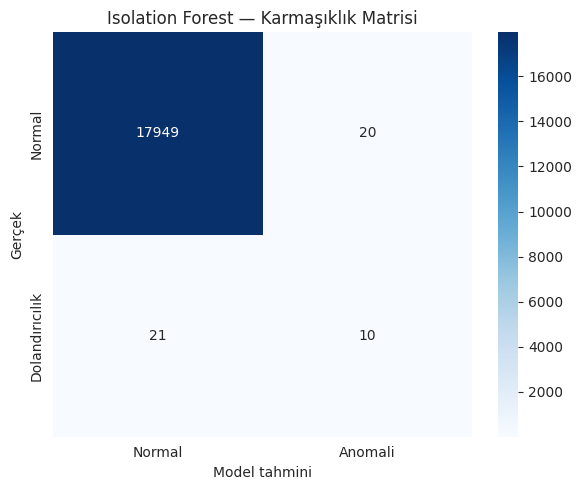

In [11]:
# ─── Değerlendirme: Etiketlerle karşılaştırma ─────────────────────────────────
print(classification_report(y_test, y_pred, target_names=["Normal", "Dolandırıcılık"], digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomali"], yticklabels=["Normal", "Dolandırıcılık"])
plt.xlabel("Model tahmini"); plt.ylabel("Gerçek")
plt.title("Isolation Forest — Karmaşıklık Matrisi")
plt.tight_layout()
plt.show()

In [12]:
# ─── Eşikten Bağımsız Metrikler ───────────────────────────────────────────────
# decision_function ne kadar düşükse o kadar anormal -> işaretini ters çeviriyoruz
anomali_skoru = -skorlar

print(f"ROC-AUC          : {roc_auc_score(y_test, anomali_skoru):.4f}")
print(f"PR-AUC (ort. kesinlik): {average_precision_score(y_test, anomali_skoru):.4f}")
print(f"\nRastgele bir modelin PR-AUC'si veri oranına eşit olurdu: {y_test.mean():.5f}")

ROC-AUC          : 0.9205
PR-AUC (ort. kesinlik): 0.2386

Rastgele bir modelin PR-AUC'si veri oranına eşit olurdu: 0.00172


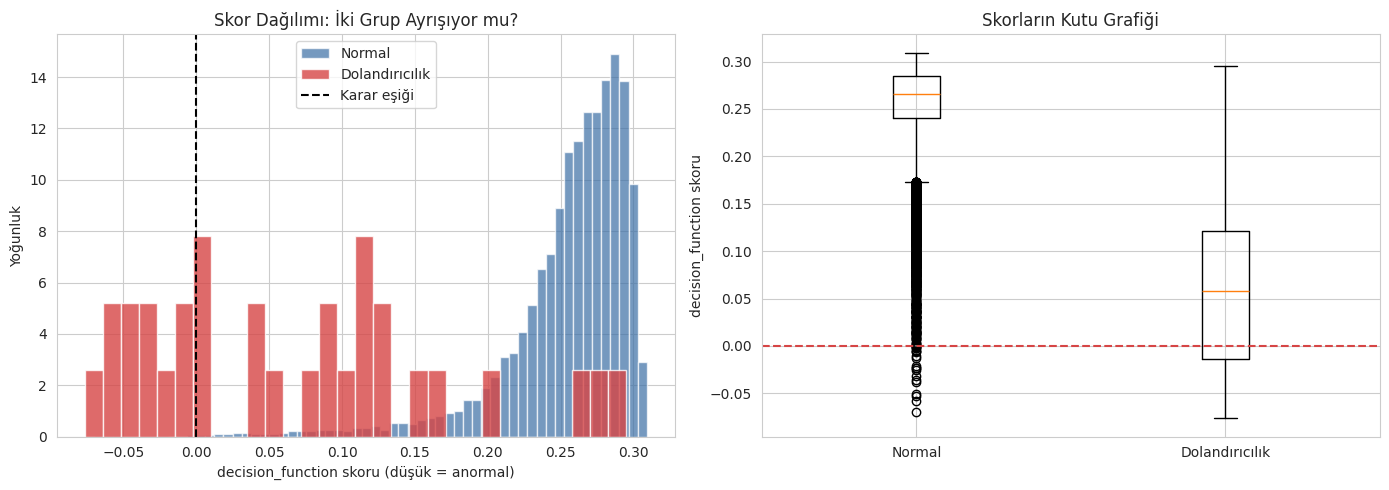

In [13]:
# ─── Anomali Skorlarının Dağılımı ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(skorlar[y_test == 0], bins=60, color="#3b6ea5", alpha=0.7,
             label="Normal", density=True)
axes[0].hist(skorlar[y_test == 1], bins=30, color="#d64545", alpha=0.8,
             label="Dolandırıcılık", density=True)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5, label="Karar eşiği")
axes[0].set_xlabel("decision_function skoru (düşük = anormal)")
axes[0].set_ylabel("Yoğunluk")
axes[0].set_title("Skor Dağılımı: İki Grup Ayrışıyor mu?")
axes[0].legend()

kutu = [skorlar[y_test == 0], skorlar[y_test == 1]]
axes[1].boxplot(kutu, labels=["Normal", "Dolandırıcılık"])
axes[1].axhline(0, color="#d64545", linestyle="--", linewidth=1.5)
axes[1].set_ylabel("decision_function skoru")
axes[1].set_title("Skorların Kutu Grafiği")

plt.tight_layout()
plt.show()

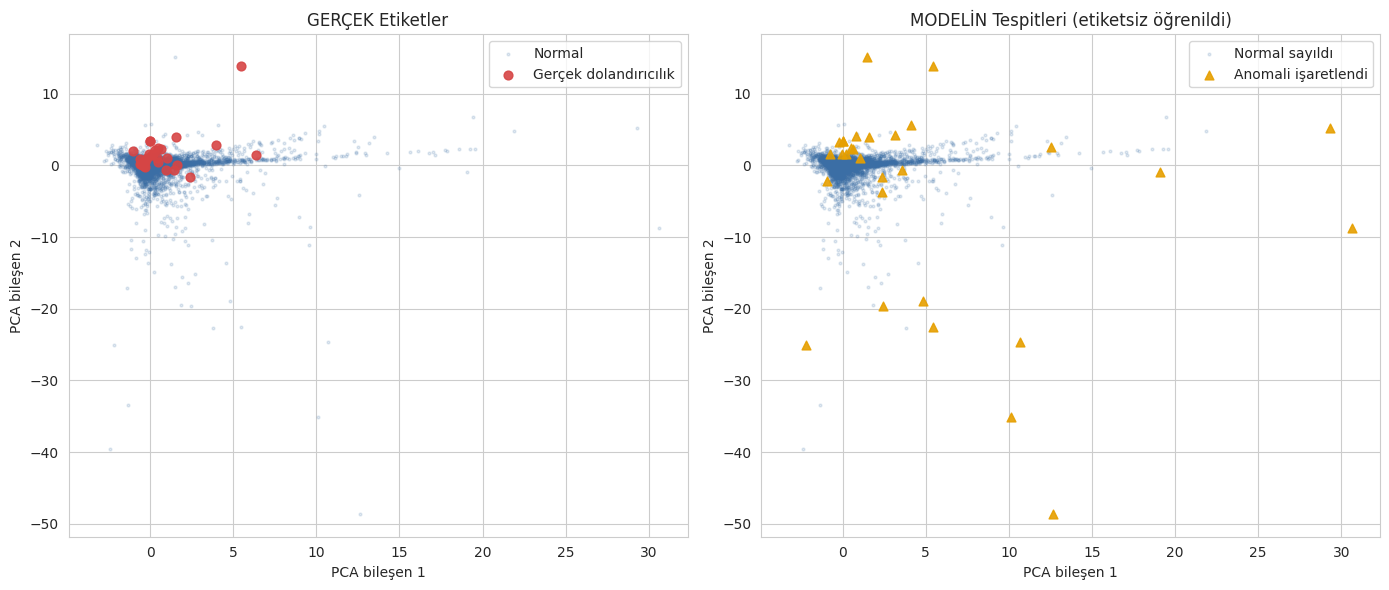

In [14]:
# ─── 2 Boyuta İndirgeyip Tespitleri Görselleştirme ────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Solda: gerçek etiketler
axes[0].scatter(X_2d[y_test == 0, 0], X_2d[y_test == 0, 1], s=4, alpha=0.15,
                color="#3b6ea5", label="Normal")
axes[0].scatter(X_2d[y_test == 1, 0], X_2d[y_test == 1, 1], s=40, alpha=0.9,
                color="#d64545", label="Gerçek dolandırıcılık")
axes[0].set_title("GERÇEK Etiketler"); axes[0].legend()

# Sağda: modelin işaretledikleri
axes[1].scatter(X_2d[y_pred == 0, 0], X_2d[y_pred == 0, 1], s=4, alpha=0.15,
                color="#3b6ea5", label="Normal sayıldı")
axes[1].scatter(X_2d[y_pred == 1, 0], X_2d[y_pred == 1, 1], s=40, alpha=0.9,
                color="#e69f00", marker="^", label="Anomali işaretlendi")
axes[1].set_title("MODELİN Tespitleri (etiketsiz öğrenildi)"); axes[1].legend()

for ax in axes:
    ax.set_xlabel("PCA bileşen 1"); ax.set_ylabel("PCA bileşen 2")
plt.tight_layout()
plt.show()

In [15]:
# ─── Contamination Parametresinin Etkisi ──────────────────────────────────────
oranlar = [0.0005, 0.001, 0.0017, 0.005, 0.01, 0.05]
satirlar = []

for c in oranlar:
    m = IsolationForest(n_estimators=200, contamination=c, max_samples=256,
                        random_state=42, n_jobs=-1).fit(X_train_s)
    p = (m.predict(X_test_s) == -1).astype(int)
    satirlar.append({
        "contamination": c,
        "İşaretlenen": int(p.sum()),
        "Precision": precision_score(y_test, p, zero_division=0),
        "Recall": recall_score(y_test, p),
        "F1": f1_score(y_test, p),
    })

sonuc_df = pd.DataFrame(satirlar).round(4)
print(sonuc_df.to_string(index=False))

 contamination  İşaretlenen  Precision  Recall     F1
        0.0005            7     0.4286  0.0968 0.1579
        0.0010           17     0.4118  0.2258 0.2917
        0.0017           30     0.3333  0.3226 0.3279
        0.0050          108     0.1389  0.4839 0.2158
        0.0100          186     0.0860  0.5161 0.1475
        0.0500          887     0.0304  0.8710 0.0588


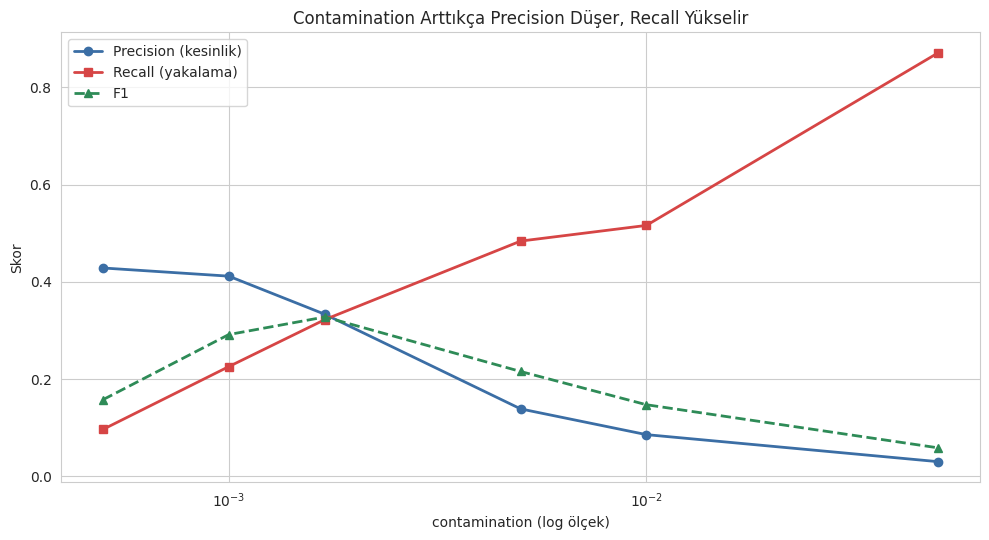

In [16]:
# ─── Precision-Recall takasının görselleştirilmesi ────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5.5))

ax1.plot(sonuc_df["contamination"], sonuc_df["Precision"], "o-",
         color="#3b6ea5", linewidth=2, label="Precision (kesinlik)")
ax1.plot(sonuc_df["contamination"], sonuc_df["Recall"], "s-",
         color="#d64545", linewidth=2, label="Recall (yakalama)")
ax1.plot(sonuc_df["contamination"], sonuc_df["F1"], "^--",
         color="#2e8b57", linewidth=2, label="F1")
ax1.set_xscale("log")
ax1.set_xlabel("contamination (log ölçek)")
ax1.set_ylabel("Skor")
ax1.set_title("Contamination Arttıkça Precision Düşer, Recall Yükselir")
ax1.legend()
plt.tight_layout()
plt.show()

In [17]:
# ─── Isolation Forest vs One-Class SVM vs Local Outlier Factor ────────────────
# NOT: One-Class SVM örnek sayısıyla karesel büyür; 42.000 satırda çok yavaş kalır.
# Bu yüzden OCSVM'i 5.000 satırlık alt örneklemle eğitiyoruz (07. pratikteki SVM dersi).
import time

alt = np.random.RandomState(42).choice(len(X_train_s), 5000, replace=False)

sonuclar = []

# 1) Isolation Forest
t0 = time.time()
m1 = IsolationForest(n_estimators=200, contamination=0.0017, max_samples=256,
                     random_state=42, n_jobs=-1).fit(X_train_s)
p1 = (m1.predict(X_test_s) == -1).astype(int)
sonuclar.append(["Isolation Forest", len(X_train_s), time.time()-t0,
                 precision_score(y_test, p1, zero_division=0),
                 recall_score(y_test, p1), f1_score(y_test, p1)])

# 2) One-Class SVM (alt örneklemle)
t0 = time.time()
m2 = OneClassSVM(kernel="rbf", nu=0.01, gamma="scale").fit(X_train_s[alt])
p2 = (m2.predict(X_test_s) == -1).astype(int)
sonuclar.append(["One-Class SVM", 5000, time.time()-t0,
                 precision_score(y_test, p2, zero_division=0),
                 recall_score(y_test, p2), f1_score(y_test, p2)])

# 3) Local Outlier Factor (novelty modunda)
t0 = time.time()
m3 = LocalOutlierFactor(n_neighbors=20, contamination=0.0017, novelty=True).fit(X_train_s[alt])
p3 = (m3.predict(X_test_s) == -1).astype(int)
sonuclar.append(["Local Outlier Factor", 5000, time.time()-t0,
                 precision_score(y_test, p3, zero_division=0),
                 recall_score(y_test, p3), f1_score(y_test, p3)])

kars = pd.DataFrame(sonuclar, columns=["Model", "Eğitim örneği", "Süre (sn)",
                                       "Precision", "Recall", "F1"]).round(4)
print(kars.to_string(index=False))

               Model  Eğitim örneği  Süre (sn)  Precision  Recall     F1
    Isolation Forest          42000     0.8724     0.3333  0.3226 0.3279
       One-Class SVM           5000     0.3697     0.0300  0.9032 0.0582
Local Outlier Factor           5000     0.6199     0.4815  0.4194 0.4483


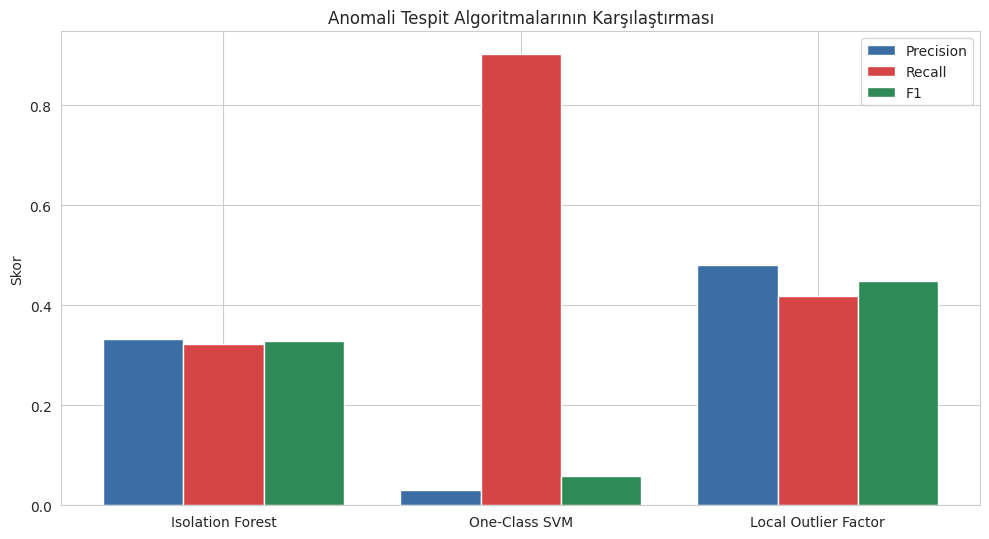

In [18]:
# ─── Karşılaştırmanın grafiği ─────────────────────────────────────────────────
x = np.arange(len(kars))
genislik = 0.27

plt.figure(figsize=(10, 5.5))
plt.bar(x - genislik, kars["Precision"], genislik, label="Precision", color="#3b6ea5")
plt.bar(x,            kars["Recall"],    genislik, label="Recall",    color="#d64545")
plt.bar(x + genislik, kars["F1"],        genislik, label="F1",        color="#2e8b57")
plt.xticks(x, kars["Model"])
plt.ylabel("Skor")
plt.title("Anomali Tespit Algoritmalarının Karşılaştırması")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# ─── Modelin En Anormal Bulduğu 10 İşlem ──────────────────────────────────────
test_df = X_test.copy()
test_df["anomali_skoru"] = -skorlar          # yüksek = daha anormal
test_df["gercek_etiket"] = y_test.values

en_anormal = test_df.nlargest(10, "anomali_skoru")[["Amount", "V14", "V17",
                                                    "anomali_skoru", "gercek_etiket"]]
print("Modelin en şüpheli bulduğu 10 işlem:")
print(en_anormal.round(3).to_string())
print(f"\nBu 10 işlemin {int(en_anormal['gercek_etiket'].sum())} tanesi gerçekten dolandırıcılık.")

Modelin en şüpheli bulduğu 10 işlem:
        Amount     V14     V17  anomali_skoru  gercek_etiket
31111     0.01   0.797 -13.033          0.076              1
13336  1235.79  -0.922  -0.009          0.070              0
22429  1860.00  -3.217  -2.141          0.058              0
40515    99.99  -4.830 -11.118          0.057              1
10526    99.99  -5.080 -11.275          0.057              1
38005     1.00   6.615   3.365          0.052              0
29150  3758.25  -2.890  -1.444          0.051              0
21235     1.00 -14.248 -12.281          0.043              1
16339     5.30 -16.338 -21.091          0.041              1
2545    264.00  -1.638  -1.413          0.038              0

Bu 10 işlemin 5 tanesi gerçekten dolandırıcılık.


In [20]:
# ─── Final Özet ───────────────────────────────────────────────────────────────
ozet = pd.DataFrame({
    "Metrik": ["Test işlem sayısı", "Gerçek dolandırıcılık", "İşaretlenen anomali",
               "Yakalanan dolandırıcılık", "Precision", "Recall", "ROC-AUC", "PR-AUC"],
    "Değer": [f"{len(y_test):,}",
              int(y_test.sum()),
              int(y_pred.sum()),
              int(((y_pred == 1) & (y_test == 1)).sum()),
              round(precision_score(y_test, y_pred, zero_division=0), 4),
              round(recall_score(y_test, y_pred), 4),
              round(roc_auc_score(y_test, anomali_skoru), 4),
              round(average_precision_score(y_test, anomali_skoru), 4)],
})
ozet

,Metrik,Değer
0,Test işlem sayısı,"18,000"
1,Gerçek dolandırıcılık,31
2,İşaretlenen anomali,30
3,Yakalanan dolandırıcılık,10
4,Precision,0.3333
5,Recall,0.3226
6,ROC-AUC,0.9205
7,PR-AUC,0.2386
